In [2]:
from pathlib import Path
from nilearn import datasets
from nilearn.datasets import _utils

DATA_DIR = Path.home() / "nilearn_data"  

_utils._REQUESTS_TIMEOUT = 300
development_dataset = datasets.fetch_development_fmri(
    n_subjects=None,
    data_dir=str(DATA_DIR),
    verbose=1,
)

[fetch_development_fmri] Dataset found in /Users/elliotwaxman/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /Users/elliotwaxman/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /Users/elliotwaxman/nilearn_data/development_fmri/development_fmri


In [3]:
import nibabel as nib
import numpy as np

img = nib.load(development_dataset.func[0])
data = img.get_fdata()  # shape (x, y, z, time)
print(data.shape)

(50, 59, 50, 168)


In [4]:
import pandas as pd
pheno = pd.read_csv(
    DATA_DIR / "development_fmri" / "development_fmri" / "participants.tsv",
    sep="\t",
)
pheno.head()

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness,ToM Booklet-Matched,ToM Booklet-Matched-NOFB,FB_Composite,FB_Group,WPPSI BD raw,WPPSI BD scaled,KBIT_raw,KBIT_standard,DCCS Summary,Scanlog: Scanner,Scanlog: Coil,Scanlog: Voxel slize,Scanlog: Slice Gap
0,sub-pixar001,4.774812,4yo,child,M,R,0.80,0.736842,6.0,pass,22.0,13.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1
1,sub-pixar002,4.856947,4yo,child,F,R,0.72,0.736842,4.0,inc,18.0,9.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.1
2,sub-pixar003,4.153320,4yo,child,F,R,0.44,0.421053,3.0,inc,15.0,9.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1
3,sub-pixar004,4.473648,4yo,child,F,R,0.64,0.736842,2.0,fail,17.0,10.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.2
4,sub-pixar005,4.837782,4yo,child,F,R,0.60,0.578947,4.0,inc,13.0,5.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.2


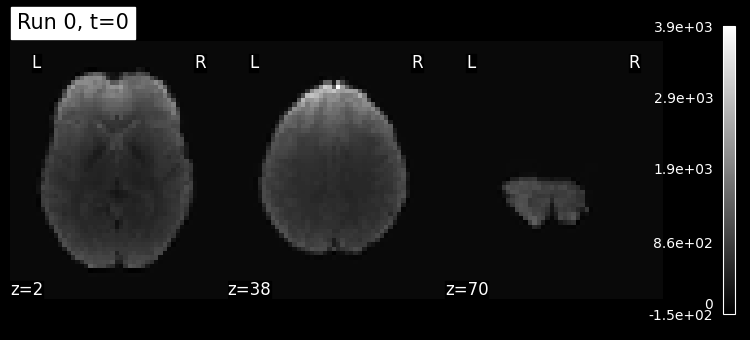

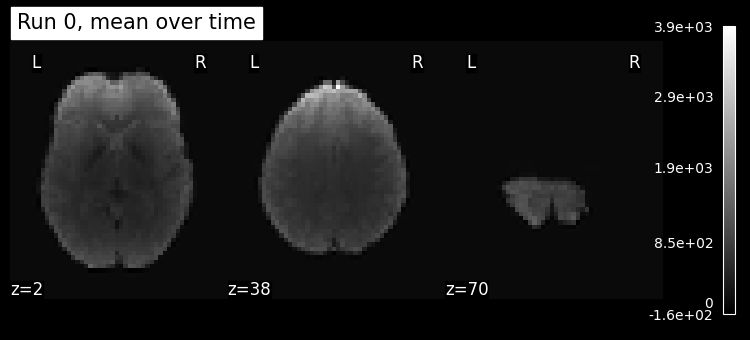

In [10]:
import matplotlib.pyplot as plt
from nilearn import image,plotting

epi_4d = development_dataset.func[0]

# One TR (e.g. first frame)
plotting.plot_epi(image.index_img(epi_4d, 0), display_mode="z", cut_coords=3, title="Run 0, t=0")

# Or middle frame
n_time = nib.load(epi_4d).shape[3]
t_mid = image.index_img(epi_4d, n_time // 2)

# Or average over time (often nicer for a quick anatomical-like EPI)
epi_mean = image.mean_img(epi_4d)
plotting.plot_epi(epi_mean, display_mode="z", cut_coords=3, title="Run 0, mean over time")

